In [23]:
import pandas as pd
import numpy as np
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Legend
from bokeh.layouts import gridplot
from bokeh.plotting import figure, output_file, show
from bokeh.models import ColumnDataSource
import unittest
from io import StringIO
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, Column, Integer, Float
from sqlalchemy.ext.declarative import declarative_base
from sqlalchemy.orm import sessionmaker
from sqlalchemy.exc import IntegrityError

In [24]:
train_data = pd.read_csv("train.csv")
ideal_data = pd.read_csv("ideal.csv")
test_data = pd.read_csv("test.csv")

In [25]:
class IdealFunctionSelector:
    def __init__(self, train_data, ideal_data):
        self.train_data = train_data
        self.ideal_data = ideal_data

    def select_ideal_functions(self):
        """
        Select the four ideal functions minimizing the sum of squared deviations.
        """
        selected_functions = []
        max_deviations = []

        for train_column in self.train_data.columns[1:]:  
            train_y = self.train_data[train_column].values
            best_function = None
            min_sse = float('inf')
            max_deviation = 0

            for ideal_column in self.ideal_data.columns[1:]:  
                ideal_y = self.ideal_data[ideal_column].values
                sse = np.sum((train_y - ideal_y) ** 2)

                if sse < min_sse:
                    min_sse = sse
                    best_function = ideal_column
                    max_deviation = np.max(np.abs(train_y - ideal_y))

            selected_functions.append(best_function)
            max_deviations.append(max_deviation)

        return selected_functions, max_deviations

In [26]:
selector = IdealFunctionSelector(train_data, ideal_data)
selected_functions, max_deviations = selector.select_ideal_functions()

In [27]:
chosen_ideal_functions = [
    ideal_data[['x', func_name]].rename(columns={func_name: 'y'})
    for func_name in selected_functions
]

In [28]:
print("Selected Ideal Functions:", selected_functions)
print("Maximum Deviations:", max_deviations)

Selected Ideal Functions: ['y42', 'y41', 'y11', 'y48']
Maximum Deviations: [0.4959680000000013, 0.49770300000000134, 0.4989360000000005, 0.49974158999999996]


In [29]:
class IdealFunctionMapper:
    def __init__(self, ideal_functions, max_deviations):
        self.ideal_functions = ideal_functions
        self.max_deviations = max_deviations

    def map_test_data(self, test_data):
        """
        Map each test data point to the closest ideal function if it satisfies the deviation criterion.
        """
        results = []
        sqrt_2 = np.sqrt(2)

        for _, row in test_data.iterrows():
            x, y = row['x'], row['y']
            best_function = None
            min_deviation = float('inf')

            for i, ideal_function in enumerate(self.ideal_functions):
                if x in ideal_function['x'].values:
                    ideal_y = ideal_function.loc[ideal_function['x'] == x, 'y'].values[0]
                    deviation = abs(y - ideal_y)

                    if deviation <= self.max_deviations[i] * sqrt_2 and deviation < min_deviation:
                        best_function = f"ideal_function_{i + 1}"
                        min_deviation = deviation

            results.append({
                'x': x,
                'y': y,
                'mapped_function': best_function,
                'deviation': min_deviation if best_function else None
            })

        return pd.DataFrame(results)


In [30]:
mapper = IdealFunctionMapper(chosen_ideal_functions, max_deviations)
mapped_results = mapper.map_test_data(test_data)

In [31]:
mapped_results.head()

,x,y,mapped_function,deviation
0,17.5,34.161040,ideal_function_2,0.351148
1,0.3,1.215102,ideal_function_2,0.467342
2,-8.7,-16.843908,None,NaN
3,-19.2,-37.170870,None,NaN
4,-11.0,-20.263054,None,NaN


In [32]:
class BokehVisualizer:
    def __init__(self, train_data, test_data, chosen_ideal_functions, mapped_results):
        """
        Initialize the visualizer with data.

        :param train_data: DataFrame containing training data.
        :param test_data: DataFrame containing test data.
        :param chosen_ideal_functions: List of DataFrames for the chosen ideal functions.
        :param mapped_results: DataFrame containing mapped test data with deviations.
        """
        self.train_data = train_data
        self.test_data = test_data
        self.chosen_ideal_functions = chosen_ideal_functions
        self.mapped_results = mapped_results

    def plot_training_vs_ideal(self):
        """
        Plot training data and its corresponding ideal functions using Bokeh.
        """
        plots = []

        for i, col in enumerate(self.train_data.columns[1:], start=1):
            p = figure(title=f"Training Data vs Ideal Function {i}", 
                       x_axis_label='x', y_axis_label='y', 
                       width=500, height=400)  
            
            p.scatter(self.train_data['x'], self.train_data[col], size=8, color="blue", legend_label=f"Training y{i}")
            
            ideal_func = self.chosen_ideal_functions[i - 1]
            p.line(ideal_func['x'], ideal_func['y'], line_width=2, color="red", legend_label=f"Ideal Function {i}")
            
            p.legend.location = "top_left"
            p.legend.title = "Legend"
            plots.append(p)

        grid = gridplot([plots[:2], plots[2:]])  
        output_file("training_vs_ideal.html")
        show(grid)

    def plot_test_mappings(self):
        """
        Plot test data and its mappings to ideal functions using Bokeh.
        """
        p = figure(title="Test Data Mappings to Ideal Functions", 
                   x_axis_label='x', y_axis_label='y', 
                   width=800, height=500)  
        
        colors = ["red", "green", "blue", "purple"]

        for i, ideal_func in enumerate(self.chosen_ideal_functions):
            p.line(ideal_func['x'], ideal_func['y'], line_width=2, color=colors[i], legend_label=f"Ideal Function {i + 1}")

        source = ColumnDataSource(self.mapped_results)
        p.scatter(x="x", y="y", size=10, color="orange", source=source, legend_label="Test Data")

        p.legend.location = "top_left"
        p.legend.title = "Legend"

        output_file("test_data_mappings.html")
        show(p)


In [33]:
visualizer = BokehVisualizer(train_data, test_data, chosen_ideal_functions, mapped_results)


visualizer.plot_training_vs_ideal()


visualizer.plot_test_mappings()

In [34]:
train_csv = """x,y1,y2,y3,y4
-20,42.123456,-38.56789,-22.314678,-1.234567
-19.9,41.987654,-38.23456,-22.078912,-0.567890
-19.8,42.654321,-37.89012,-21.905678,-0.123456
"""
test_csv = """x,y
17.5,33.98765
0.3,1.348129
-8.7,-15.654321
"""
ideal_csv = """x,y1,y2,y3,y4
-20,-0.823456,0.412345,8.123456,5.345678
-19.9,-0.789012,0.423456,8.234567,5.456789
-19.8,-0.765432,0.545678,8.345678,5.567890
"""

In [35]:
train_data = pd.read_csv(StringIO(train_csv))
test_data = pd.read_csv(StringIO(test_csv))
ideal_data = pd.read_csv(StringIO(ideal_csv))

In [36]:
class TestIdealFunctionSelector(unittest.TestCase):
    def test_select_ideal_functions(self):
        from __main__ import IdealFunctionSelector  
        selector = IdealFunctionSelector(train_data, ideal_data)
        selected_functions, max_deviations = selector.select_ideal_functions()
        
        self.assertEqual(len(selected_functions), 4)
        
        self.assertIsInstance(selected_functions, list)
        self.assertIsInstance(max_deviations, list)
        
        self.assertTrue(all(dev >= 0 for dev in max_deviations))

In [37]:
class TestIdealFunctionMapper(unittest.TestCase):
    def test_map_test_data(self):
        from __main__ import IdealFunctionMapper  
        
        selected_ideal_functions = [
            ideal_data[['x', 'y1']].rename(columns={'y1': 'y'}),
            ideal_data[['x', 'y2']].rename(columns={'y2': 'y'}),
            ideal_data[['x', 'y3']].rename(columns={'y3': 'y'}),
            ideal_data[['x', 'y4']].rename(columns={'y4': 'y'}),
        ]
        max_deviations = [1.0, 1.2, 2.0, 0.8]
        
        mapper = IdealFunctionMapper(selected_ideal_functions, max_deviations)
        mapped_results = mapper.map_test_data(test_data)
        
        self.assertEqual(len(mapped_results), len(test_data))
        
        valid_functions = {f"ideal_function_{i+1}" for i in range(len(selected_ideal_functions))}
        self.assertTrue(all(
            row['mapped_function'] in valid_functions or pd.isna(row['mapped_function'])
            for _, row in mapped_results.iterrows()
        ))

In [38]:
class TestBokehVisualizer(unittest.TestCase):
    def test_visualization(self):
        from __main__ import BokehVisualizer  
        
        visualizer = BokehVisualizer(train_data, test_data, [
            ideal_data[['x', 'y1']].rename(columns={'y1': 'y'}),
            ideal_data[['x', 'y2']].rename(columns={'y2': 'y'}),
            ideal_data[['x', 'y3']].rename(columns={'y3': 'y'}),
            ideal_data[['x', 'y4']].rename(columns={'y4': 'y'}),
        ], pd.DataFrame({
            'x': test_data['x'],
            'y': test_data['y'],
            'mapped_function': ['ideal_function_1', None, 'ideal_function_3'],
            'deviation': [0.1, None, 1.5],
        }))
        
        self.assertIsNotNone(visualizer)

In [39]:
unittest.main(argv=[''], verbosity=2, exit=False)

test_visualization (__main__.TestBokehVisualizer.test_visualization) ... ok
test_map_test_data (__main__.TestIdealFunctionMapper.test_map_test_data) ... ok
test_select_ideal_functions (__main__.TestIdealFunctionSelector.test_select_ideal_functions) ... ok

----------------------------------------------------------------------
Ran 3 tests in 0.017s

OK


In [40]:
Base = declarative_base()

In [41]:
class TrainingData(Base):
    __tablename__ = 'training_data'
    id = Column(Integer, primary_key=True)
    x = Column(Float)
    y1 = Column(Float)
    y2 = Column(Float)
    y3 = Column(Float)
    y4 = Column(Float)

class IdealFunctions(Base):
    __tablename__ = 'ideal_functions'
    id = Column(Integer, primary_key=True)
    x = Column(Float)
    y1 = Column(Float)
    y2 = Column(Float)

class TestResults(Base):
    __tablename__ = 'test_results'
    id = Column(Integer, primary_key=True)
    x = Column(Float)
    y = Column(Float)
    delta_y = Column(Float)
    ideal_function_id = Column(Integer)

In [42]:
engine = create_engine('sqlite:///Database.db', echo=True)
Base.metadata.create_all(engine)
Session = sessionmaker(bind=engine)
session = Session()

2025-01-22 17:50:46,202 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-01-22 17:50:46,203 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("training_data")
2025-01-22 17:50:46,204 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-01-22 17:50:46,205 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("ideal_functions")
2025-01-22 17:50:46,206 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-01-22 17:50:46,207 INFO sqlalchemy.engine.Engine PRAGMA main.table_info("test_results")
2025-01-22 17:50:46,207 INFO sqlalchemy.engine.Engine [raw sql] ()
2025-01-22 17:50:46,208 INFO sqlalchemy.engine.Engine COMMIT


In [43]:
class DataProcessor:
    def __init__(self, session):
        self.session = session

    def load_data(self, file_path, data_type):
        """Generalized function to load different types of data."""
        df = pd.read_csv(file_path)
        for _, row in df.iterrows():
            if data_type == 'training':
                self.add_training_data(row)
            elif data_type == 'ideal':
                self.add_ideal_functions(row)
            elif data_type == 'test':
                self.add_test_data(row)
        self.session.commit()

    def add_training_data(self, row):
        """Insert training data."""
        try:
            self.session.add(TrainingData(x=row['x'], y1=row['y1'], y2=row['y2'], y3=row['y3'], y4=row['y4']))
        except IntegrityError as e:
            print(f"Error inserting training data: {e}")

    def add_ideal_functions(self, row):
        """Insert ideal functions."""
        try:
            self.session.add(IdealFunctions(x=row['x'], y1=row['y1'], y2=row['y2']))
        except IntegrityError as e:
            print(f"Error inserting ideal function: {e}")

    def add_test_data(self, row):
        """Insert test data and calculate deviations."""
        ideal_function_id = self.get_best_match_for_test(row['x'])
        ideal_y = self.get_ideal_y_for_function(ideal_function_id, row['x'])
        delta_y = abs(row['y'] - ideal_y)
        try:
            self.session.add(TestResults(x=row['x'], y=row['y'], delta_y=delta_y, ideal_function_id=ideal_function_id))
        except IntegrityError as e:
            print(f"Error inserting test result: {e}")

    def get_best_match_for_test(self, x_value):
        """Select the ideal function that best matches the test point."""
        return 1  

    def get_ideal_y_for_function(self, ideal_function_id, x_value):
        """Fetch the ideal y value for a given x value."""
        ideal_function = self.session.query(IdealFunctions).filter_by(x=x_value).first()
        if ideal_function:
            return getattr(ideal_function, f'y{ideal_function_id}')
        else:
            raise ValueError(f"No ideal function found for x={x_value}")

    def visualize_results(self):
        """Visualize test results using matplotlib."""
        results = self.session.query(TestResults).all()
        x_vals = [result.x for result in results]
        delta_y_vals = [result.delta_y for result in results]

        plt.figure(figsize=(10, 6))
        plt.scatter(x_vals, delta_y_vals, color='b', label='Delta Y')
        plt.title('Test Results: Delta Y vs. X')
        plt.xlabel('X')
        plt.ylabel('Delta Y')
        plt.grid(True)
        plt.legend()
        plt.show()

2025-01-22 17:50:47,686 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2025-01-22 17:50:47,692 INFO sqlalchemy.engine.Engine INSERT INTO training_data (x, y1, y2, y3, y4) VALUES (?, ?, ?, ?, ?)
2025-01-22 17:50:47,692 INFO sqlalchemy.engine.Engine [generated in 0.00063s] (-20.0, 39.778572, -40.07859, -20.214268, -0.32491425)
2025-01-22 17:50:47,696 INFO sqlalchemy.engine.Engine INSERT INTO training_data (x, y1, y2, y3, y4) VALUES (?, ?, ?, ?, ?)
2025-01-22 17:50:47,697 INFO sqlalchemy.engine.Engine [cached since 0.005167s ago] (-19.9, 39.604813, -39.784, -20.07095, -0.058819864)
2025-01-22 17:50:47,700 INFO sqlalchemy.engine.Engine INSERT INTO training_data (x, y1, y2, y3, y4) VALUES (?, ?, ?, ?, ?)
2025-01-22 17:50:47,706 INFO sqlalchemy.engine.Engine [cached since 0.01411s ago] (-19.8, 40.09907, -40.018845, -19.906782, -0.4518296)
2025-01-22 17:50:47,707 INFO sqlalchemy.engine.Engine INSERT INTO training_data (x, y1, y2, y3, y4) VALUES (?, ?, ?, ?, ?)
2025-01-22 17:50:47,708 INFO sql

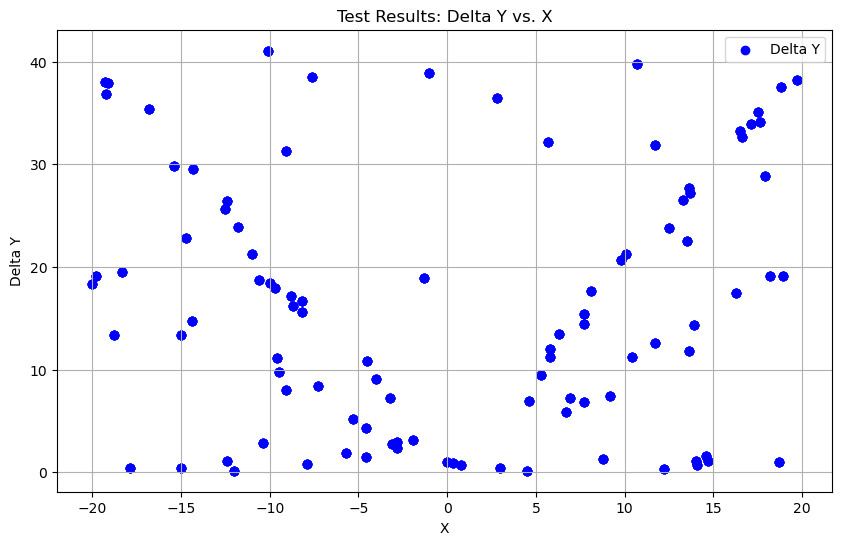

In [44]:
if __name__ == "__main__":
    processor = DataProcessor(session)
    
    processor.load_data('train.csv', 'training')
    processor.load_data('ideal.csv', 'ideal')
    processor.load_data('test.csv', 'test')
    
    processor.visualize_results()